### Dotplot -> Distribution(Percentage) of adaptive cells classified as iML across samples
### Pydeseq2- iML vs adaptive

In [ ]:
# Python version 3.10.14

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
from matplotlib import rcParams
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import harmonypy 

In [2]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.h5ad")

In [3]:
adata.obs

,sample,batch,subset,dataset,source,total_counts,n_genes_by_counts,pct_counts_mt,_scvi_batch,_scvi_labels,...,HALLMARK_GLYCOLYSIS_auc,HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc,subset_source,bright_dim_subset,reference,Malmberg_patient,patient_ID,dataset_v2,patient_ID_v2,classification
AAACCTGAGTGTCCAT_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1345.0,725.0,2.304833,401,0,...,0.041626,0.005439,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,CD56dim
AAACCTGCACATGGGA_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,2108.0,884.0,2.182163,401,0,...,0.033480,0.000000,NKG2A+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,ML1
AAACCTGCACCTCGGA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1821.0,853.0,2.471170,401,0,...,0.054942,0.000000,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,CD56dim
AAACCTGGTTGAGTTC_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,1294.0,753.0,2.086553,401,0,...,0.041032,0.018933,NKG2A+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,ML1
AAACCTGTCACCGTAA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1637.0,831.0,1.710446,401,0,...,0.035483,0.013773,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,CD56dim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rGBM-04-4_TAAGTCGGTTCTTGCC-1-0-1_abdelfattah_rGBM-04,rGBM-04,rGBM-04,TiCD56bright,abdelfattah,glioblastoma,2693.0,1184.0,3.564798,843,0,...,0.028977,0.000000,TiCD56bright_glioblastoma,CD56bright,tumor,rGBM-04_abdelfattah,rGBM-04_abdelfattah,abdelfattah,rGBM-04_abdelfattah,CD56dim
rGBM-05-2_ATATCCTAGTCATACC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,1946.0,1059.0,1.593011,844,0,...,0.055180,0.026290,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah,CD56dim
rGBM-05-2_CCCTCAACATAGACTC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,2335.0,1371.0,2.655246,844,0,...,0.038762,0.006032,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah,CD56dim
rGBM-05-3_AGGAAATCATTCATCT-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,5610.0,1888.0,8.039216,844,0,...,0.034727,0.000000,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah,CD56dim


In [ ]:
# subsetted malmberg data to include only PBMC

In [7]:
adata= adata[adata.obs['source'] == 'PBMC'].copy()
adata

AnnData object with n_obs × n_vars = 23120 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [9]:
adata.obs['group'] = adata.obs['classification']

In [10]:
adata.obs["group"].value_counts()

group
CD56dim          18912
CD56bright        1280
ML1               1271
ML_transition      851
ML2                503
unclassified       303
Name: count, dtype: int64

In [ ]:
# combining iML1, iML2 and iML_transition to iML

In [11]:

adata.obs['group'] = adata.obs['group'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_20325/2866071085.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['group'] = adata.obs['group'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})


In [12]:
# Make sure it's categorical
adata.obs['classification_v2'] = adata.obs['group'].astype('category')

# Add 'Adaptive' to the categories
adata.obs['classification_v2'] = adata.obs['classification_v2'].cat.add_categories(['Adaptive'])

# Now assign adaptive cells from malmberg subset column, except for iML category
mask = (adata.obs['subset'] == 'Adaptive') & (adata.obs['classification_v2'] != 'iML')
adata.obs.loc[mask, 'classification_v2'] = 'Adaptive'
adata.obs['classification_v2'] = adata.obs['classification_v2'].cat.remove_unused_categories()

In [13]:
adata.obs["group"].value_counts()

group
CD56dim         18912
iML              2625
CD56bright       1280
unclassified      303
Name: count, dtype: int64

In [14]:
adata.obs["classification_v2"].value_counts()

classification_v2
CD56dim         17580
iML              2625
Adaptive         1344
CD56bright       1271
unclassified      300
Name: count, dtype: int64

In [15]:
adata = adata[adata.obs["classification_v2"] != "unclassified"].copy()

In [16]:
adata.obs["classification_v2"].value_counts()

classification_v2
CD56dim       17580
iML            2625
Adaptive       1344
CD56bright     1271
Name: count, dtype: int64

In [18]:
adata.obs['classification_v3'] = adata.obs['group'].astype('category')
adata.obs['classification_v3'] = adata.obs['classification_v3'].cat.add_categories(['Adaptive'])
adata.obs.loc[adata.obs['subset'] == 'Adaptive', 'classification_v3'] = 'Adaptive'

# Total number of 'iML' in 'group'
total_iML = (adata.obs['group'] == 'iML').sum()

# Number of 'iML' that are now 'Adaptive' in 'classification_v2'
iML_to_adaptive = ((adata.obs['group'] == 'iML') & 
                   (adata.obs['classification_v3'] == 'Adaptive')).sum()

# Percentage
percent_replaced = (iML_to_adaptive / total_iML) * 100

print(f"{percent_replaced:.2f}% of iML in 'group' were replaced with 'Adaptive'")
print(iML_to_adaptive)
print(total_iML)


3.96% of iML in 'group' were replaced with 'Adaptive'
104
2625


In [61]:
plt.rcParams['figure.dpi'] = 600

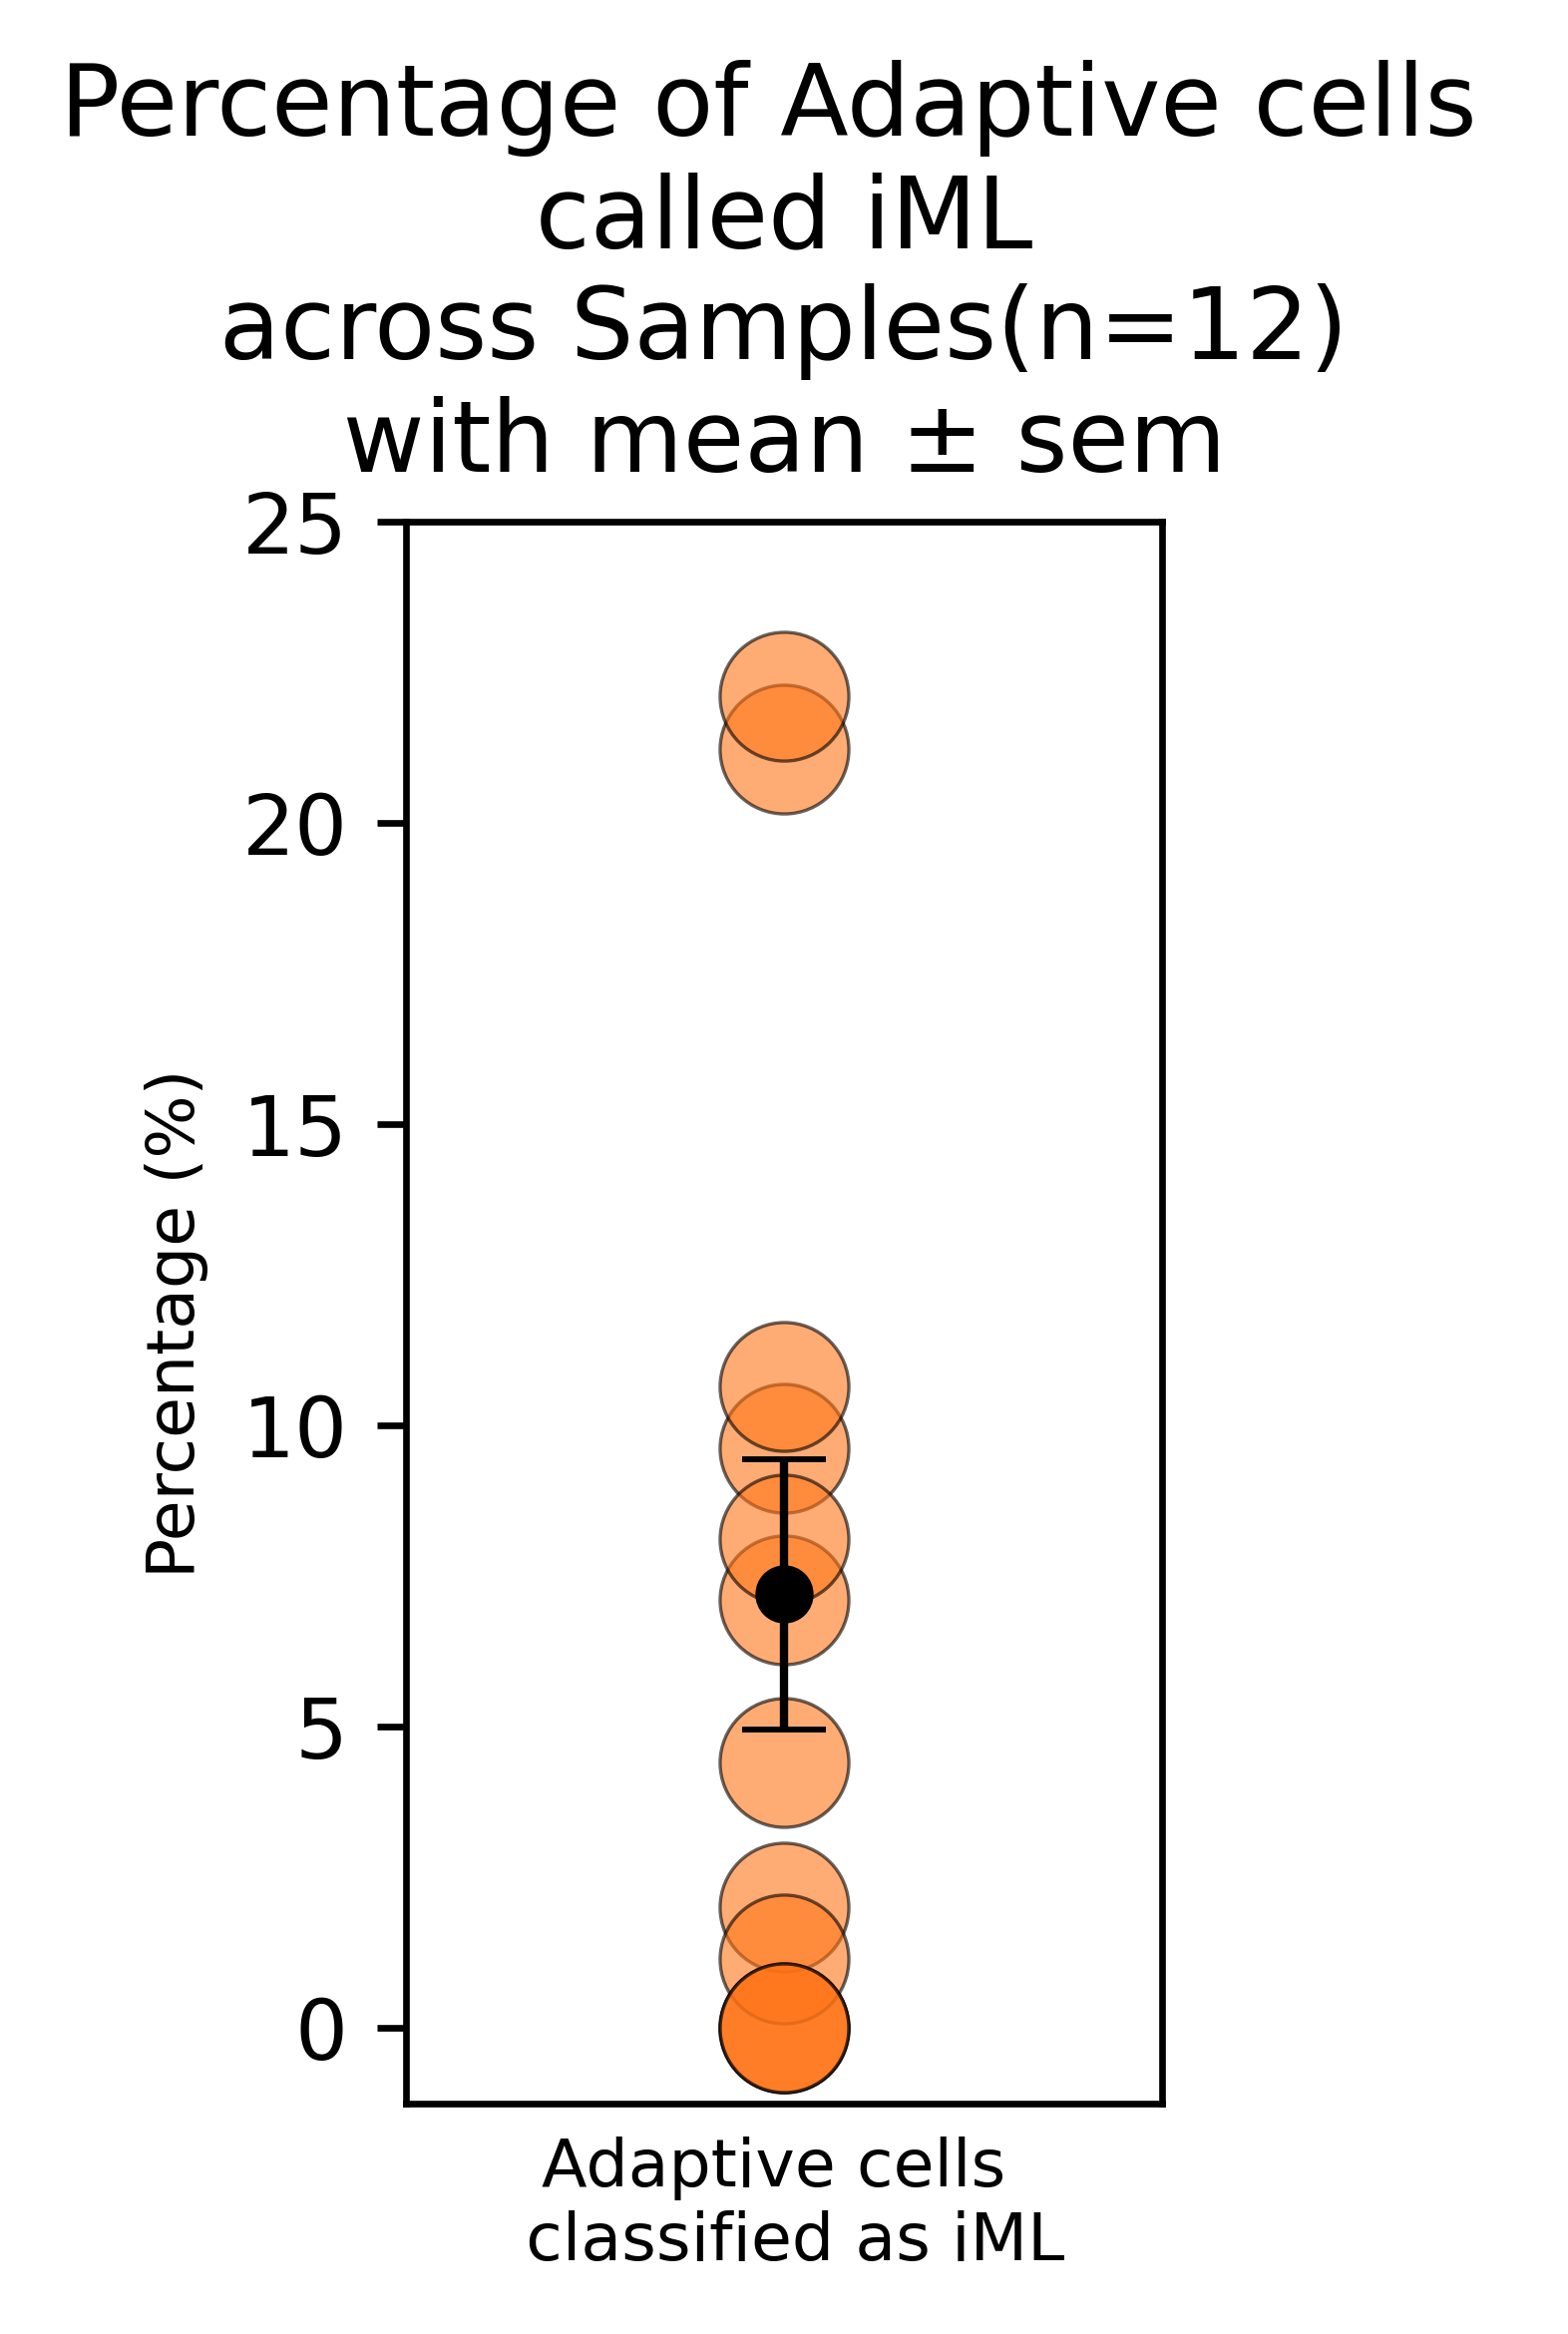

In [71]:
from scipy import stats
# Calculate % of Adaptive cells that were called iML, per donor
donor_percentages = []
donors = []

for sample in adata.obs['sample'].unique():
    # Subset data for this donor
    sample_data = adata.obs[adata.obs['sample'] == sample]
    
    # Total Adaptive cells for this donor
    total_adaptive = (sample_data['classification_v3'] == 'Adaptive').sum()
    
    # Adaptive cells that were called iML
    adaptive_from_iML = ((sample_data['classification_v3'] == 'Adaptive') & 
                         (sample_data['group'] == 'iML')).sum()
    
    # Calculate percentage (only if there are Adaptive cells)
    if total_adaptive > 0:
        percent = (adaptive_from_iML / total_adaptive) * 100
        donor_percentages.append(percent)
        donors.append(sample)
    else:
        # If no Adaptive cells, skip this donor or set to 0
        pass

# Calculate mean and SEM
mean_percent = np.mean(donor_percentages)
sem_percent = stats.sem(donor_percentages)


# Create scatter plot
fig, ax = plt.subplots(figsize=(2, 4))

# Plot individual donor points
x_positions = np.zeros(len(donor_percentages))
ax.scatter(x_positions, donor_percentages, s=240, alpha=0.6, 
           color='#FF7518', edgecolors='black', linewidth=0.4, zorder=3)

# Plot mean with SEM error bars
ax.errorbar(0, mean_percent, yerr=sem_percent, fmt='o', 
            color='black',  capsize=5, capthick=0.7,  markersize=6,
            elinewidth=1,label=f'Mean ± SEM', zorder=3)

plt.title('Percentage of Adaptive cells \n called iML \n across Samples(n=12) \n with mean ± sem ', fontsize=12)

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-1.25, 25)
ax.set_ylabel('Percentage (%) ', fontsize=8)
ax.set_xlabel('Adaptive cells \n classified as iML', fontsize=8)
ax.set_xticks([])
plt.tight_layout()
plt.show()


In [ ]:
adata.obs['classification_v3'].value_counts()

classification_v3
CD56dim         17580
iML              2521
Adaptive         1448
CD56bright       1271
unclassified        0
Name: count, dtype: int64

In [ ]:
# categories from which Adaptive cells come from
adaptive_cells = adata.obs[adata.obs['classification_v3'] == 'Adaptive']
print(adaptive_cells['group'].value_counts())
print()
# As percentage
print("=== As percentage ===")
print(adaptive_cells['group'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

group
CD56dim         1332
iML              104
CD56bright         9
unclassified       3
Name: count, dtype: int64

=== As percentage ===
group
CD56dim         91.99%
iML              7.18%
CD56bright       0.62%
unclassified     0.21%
Name: proportion, dtype: object


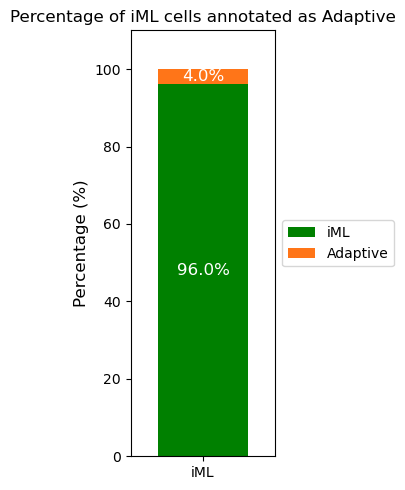

In [ ]:
# Percentages
percent_adaptive = (iML_to_adaptive / total_iML) * 100
percent_not_adaptive = 100 - percent_adaptive

# Data for stacked bar
categories = ['iML']
adaptive = [percent_adaptive]
not_adaptive = [percent_not_adaptive]

# Plot
plt.figure(figsize=(3.5,5))
plt.bar(categories, not_adaptive, color='green', label='iML')
plt.bar(categories, adaptive, bottom=not_adaptive, color='#FF7518', label='Adaptive')

# Add percentage text
plt.text(0, percent_not_adaptive / 2, f"{percent_not_adaptive:.1f}%", ha='center', va='center', color='white', fontsize=12)
plt.text(0, percent_not_adaptive + percent_adaptive / 2, f"{percent_adaptive:.1f}%", ha='center', va='center', color='white', fontsize=12)

plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Percentage of iML cells annotated as Adaptive')
plt.ylim(0, 110)
plt.margins(x=0.3) 
# Legend on the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


In [ ]:
# Adaptive markers

In [ ]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
sc.pp.scale(adata, zero_center=True, max_value=None)

/Users/vedanagapriyavangala/anaconda3/envs/python310/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
plt.rcParams['figure.dpi'] = 600

In [ ]:
new_order = ["CD56bright", "CD56dim", "iML", "Adaptive"]   

# Make column categorical and reorder
adata.obs['classification_v2'] = (
    adata.obs['classification_v2']
    .astype('category')
    .cat.reorder_categories(new_order, ordered=True)
)

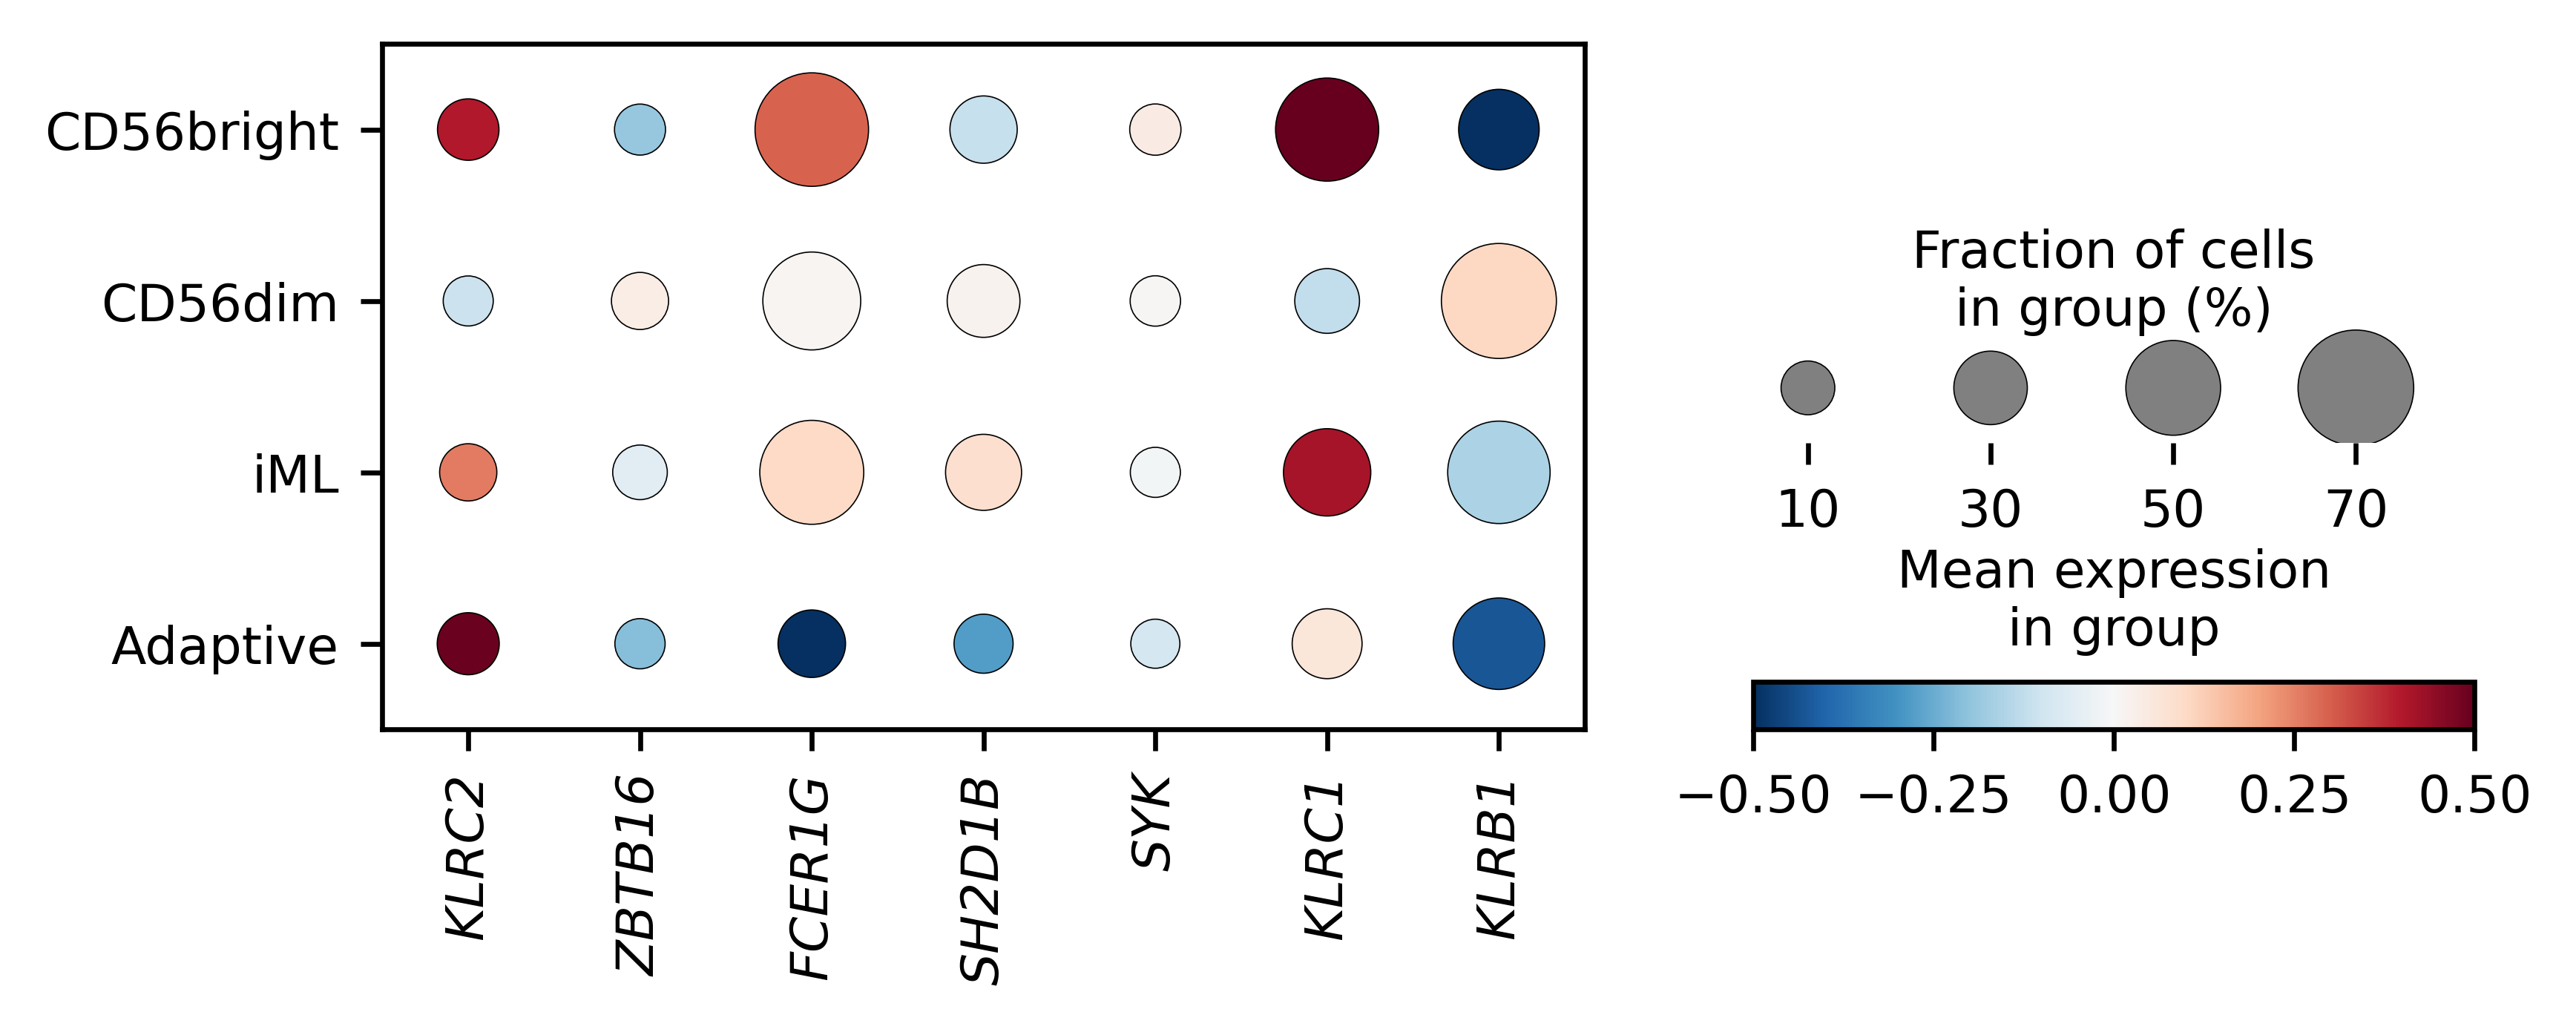

In [ ]:
genes = ["KLRC2","ZBTB16", "FCER1G", "SH2D1B", "SYK", "KLRC1", "KLRB1"]

# Generate a combined dot plot and modify it
dp = sc.pl.dotplot(adata, var_names=genes, groupby='classification_v2',  use_raw=False, 
                    cmap='RdBu_r',
                      #title="Adaptive markers in Malmberg PBMC ", 
                      figsize=(4, 2),
                    vmin=-0.5, vmax=0.5,return_fig=True, show=False )

dp.style(
    smallest_dot=60,
    largest_dot=350,
    cmap='RdBu_r',
    color_on='white'
)
# Make gene names italic
ax = dp.get_axes()
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')

plt.subplots_adjust(right=1.3)  
plt.show()

## Pydeseq2- iML vs Adaptive

In [ ]:
import warnings
import decoupler as dc
import pertpy as pt
import scanpy as sc
warnings.filterwarnings("ignore")

In [ ]:
#pseudobulk

In [ ]:
pdata = dc.pp.pseudobulk(adata, sample_col="patient_ID_v2", groups_col="classification_v2", layer="counts", mode="sum")

In [ ]:
dc.pp.filter_samples(pdata, inplace=True)
pdata

AnnData object with n_obs × n_vars = 47 × 14337
    obs: 'patient_ID_v2', 'classification_v2', 'sample', 'batch', 'dataset', 'source', '_scvi_batch', '_scvi_labels', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    layers: 'psbulk_props'

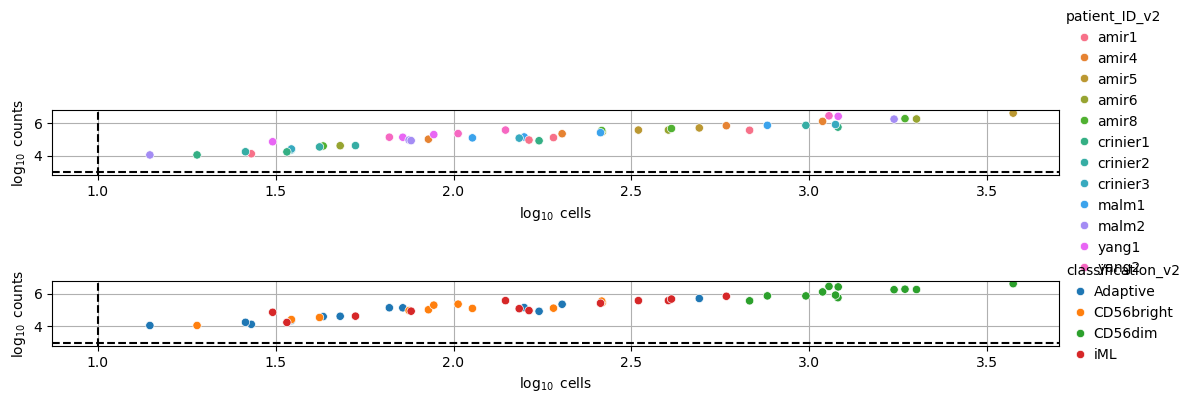

In [ ]:
dc.pl.filter_samples(pdata, groupby=["patient_ID_v2", "classification_v2"], figsize=(12, 4))

In [ ]:
pdata.layers["counts"] = pdata.X.copy()

sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.pp.pca(pdata)

In [ ]:
dc.pp.swap_layer(pdata, "counts", inplace=True)

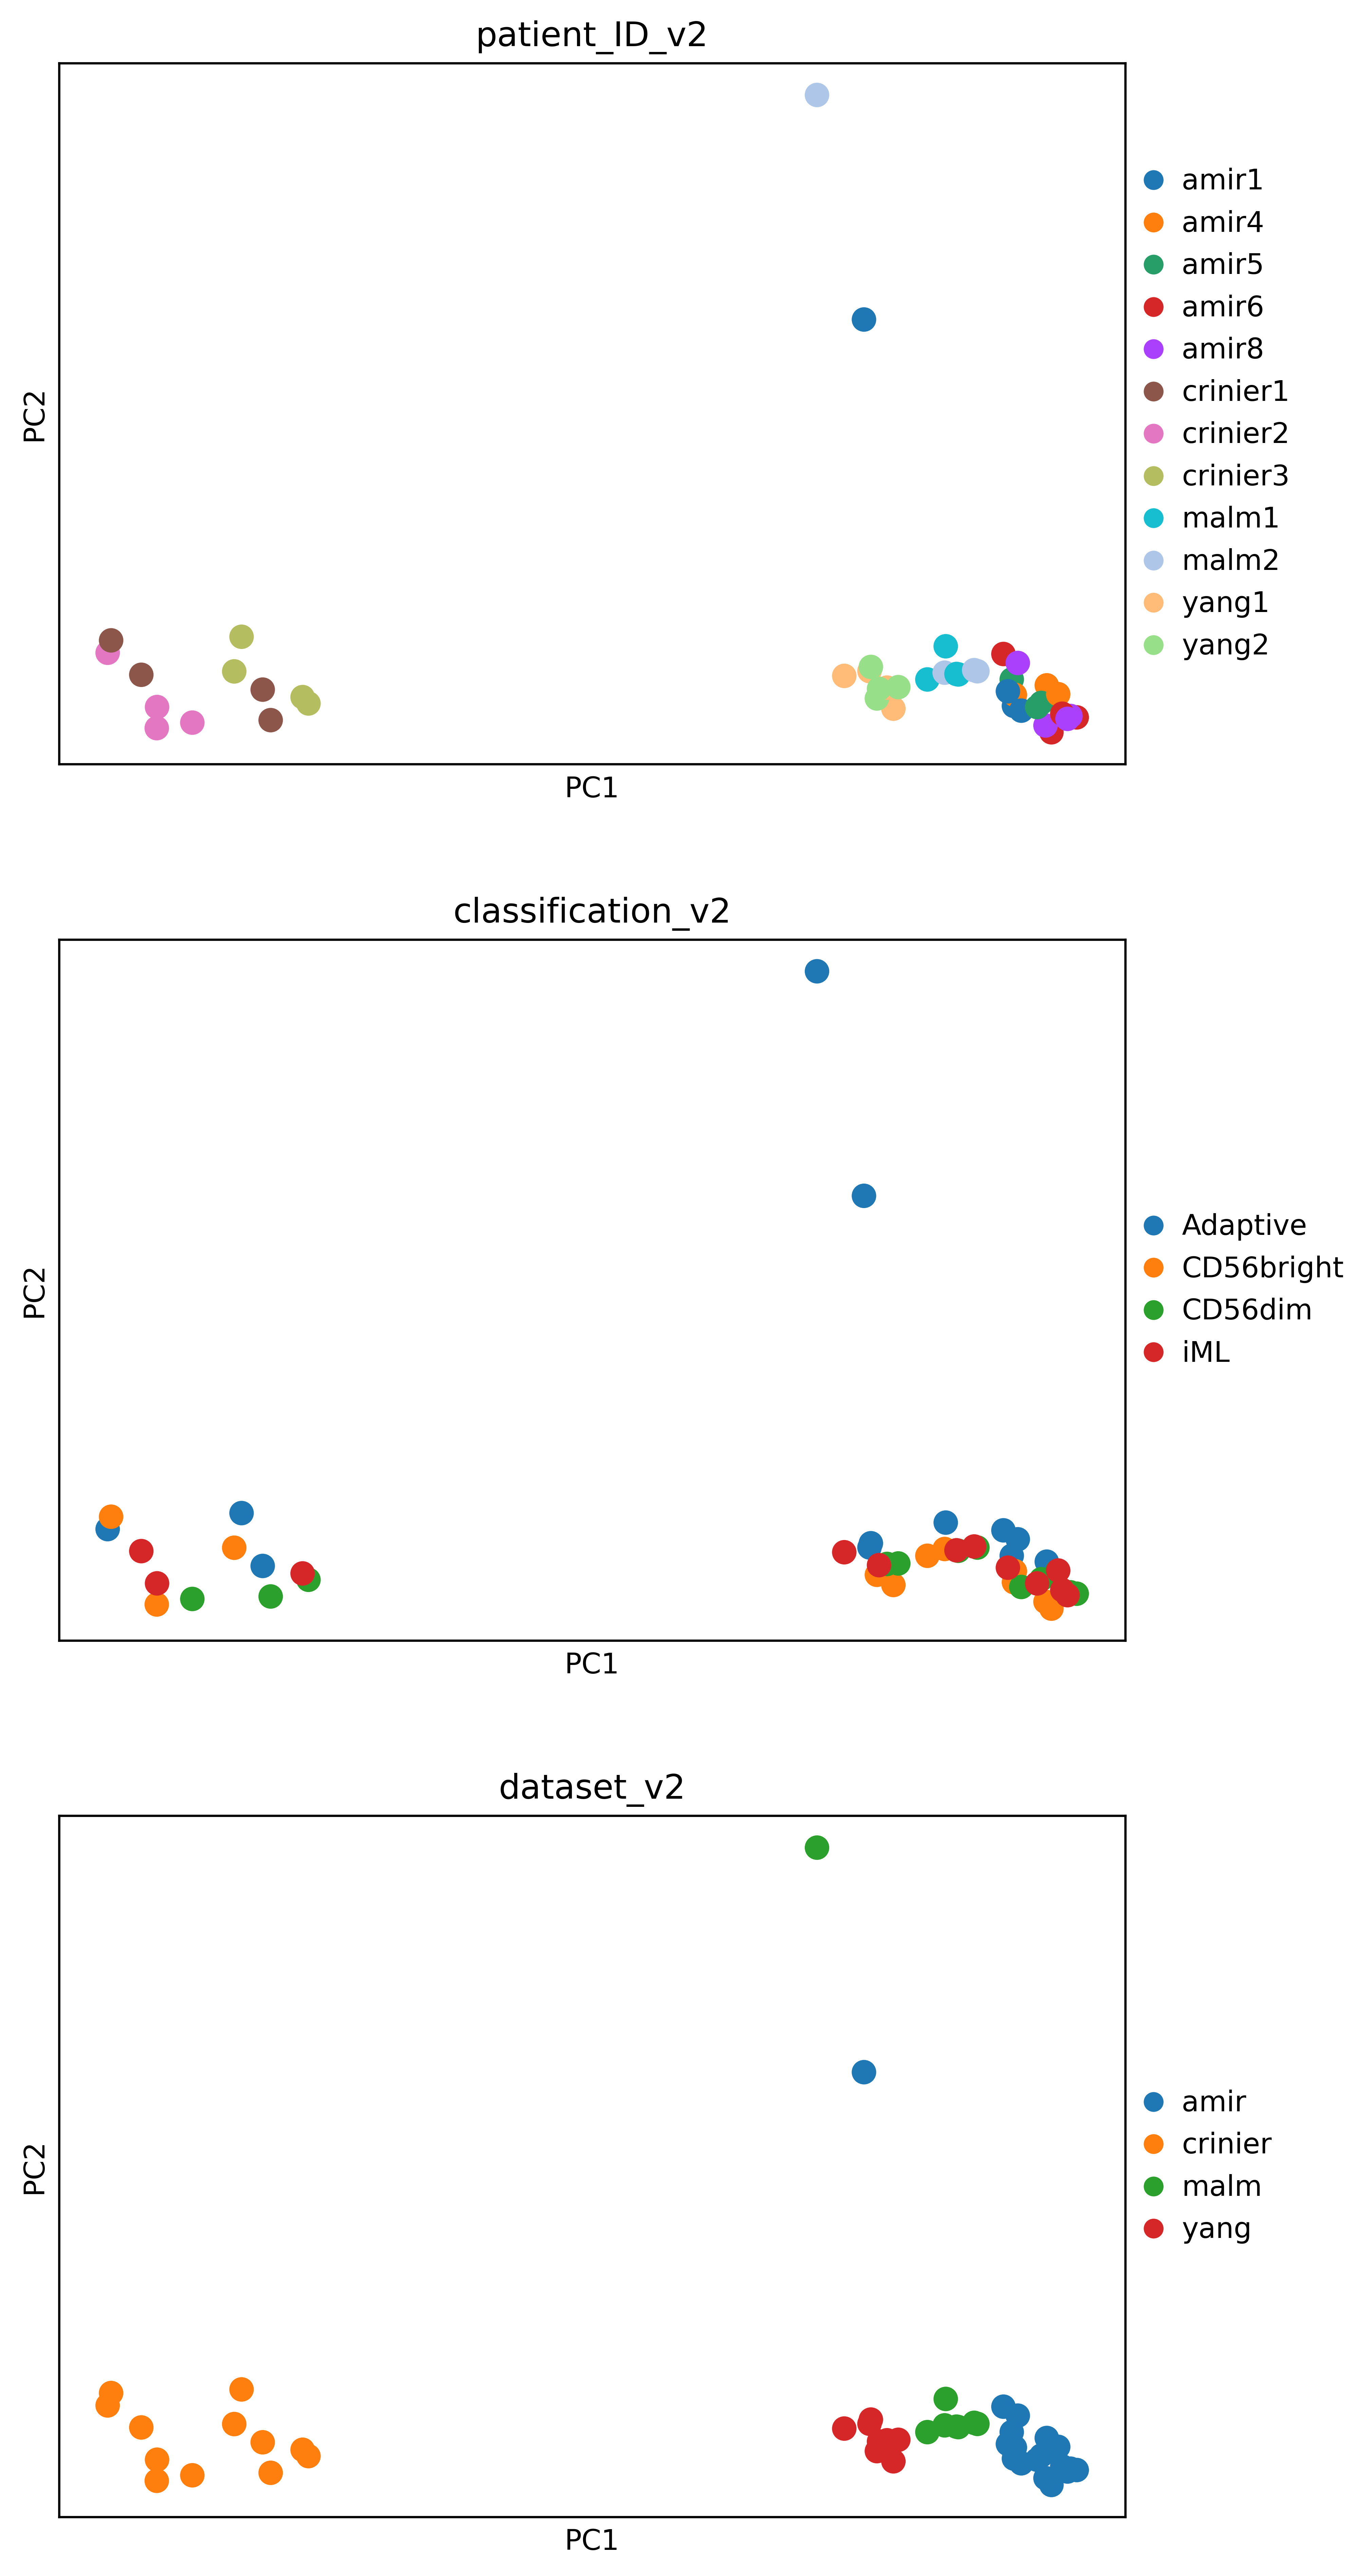

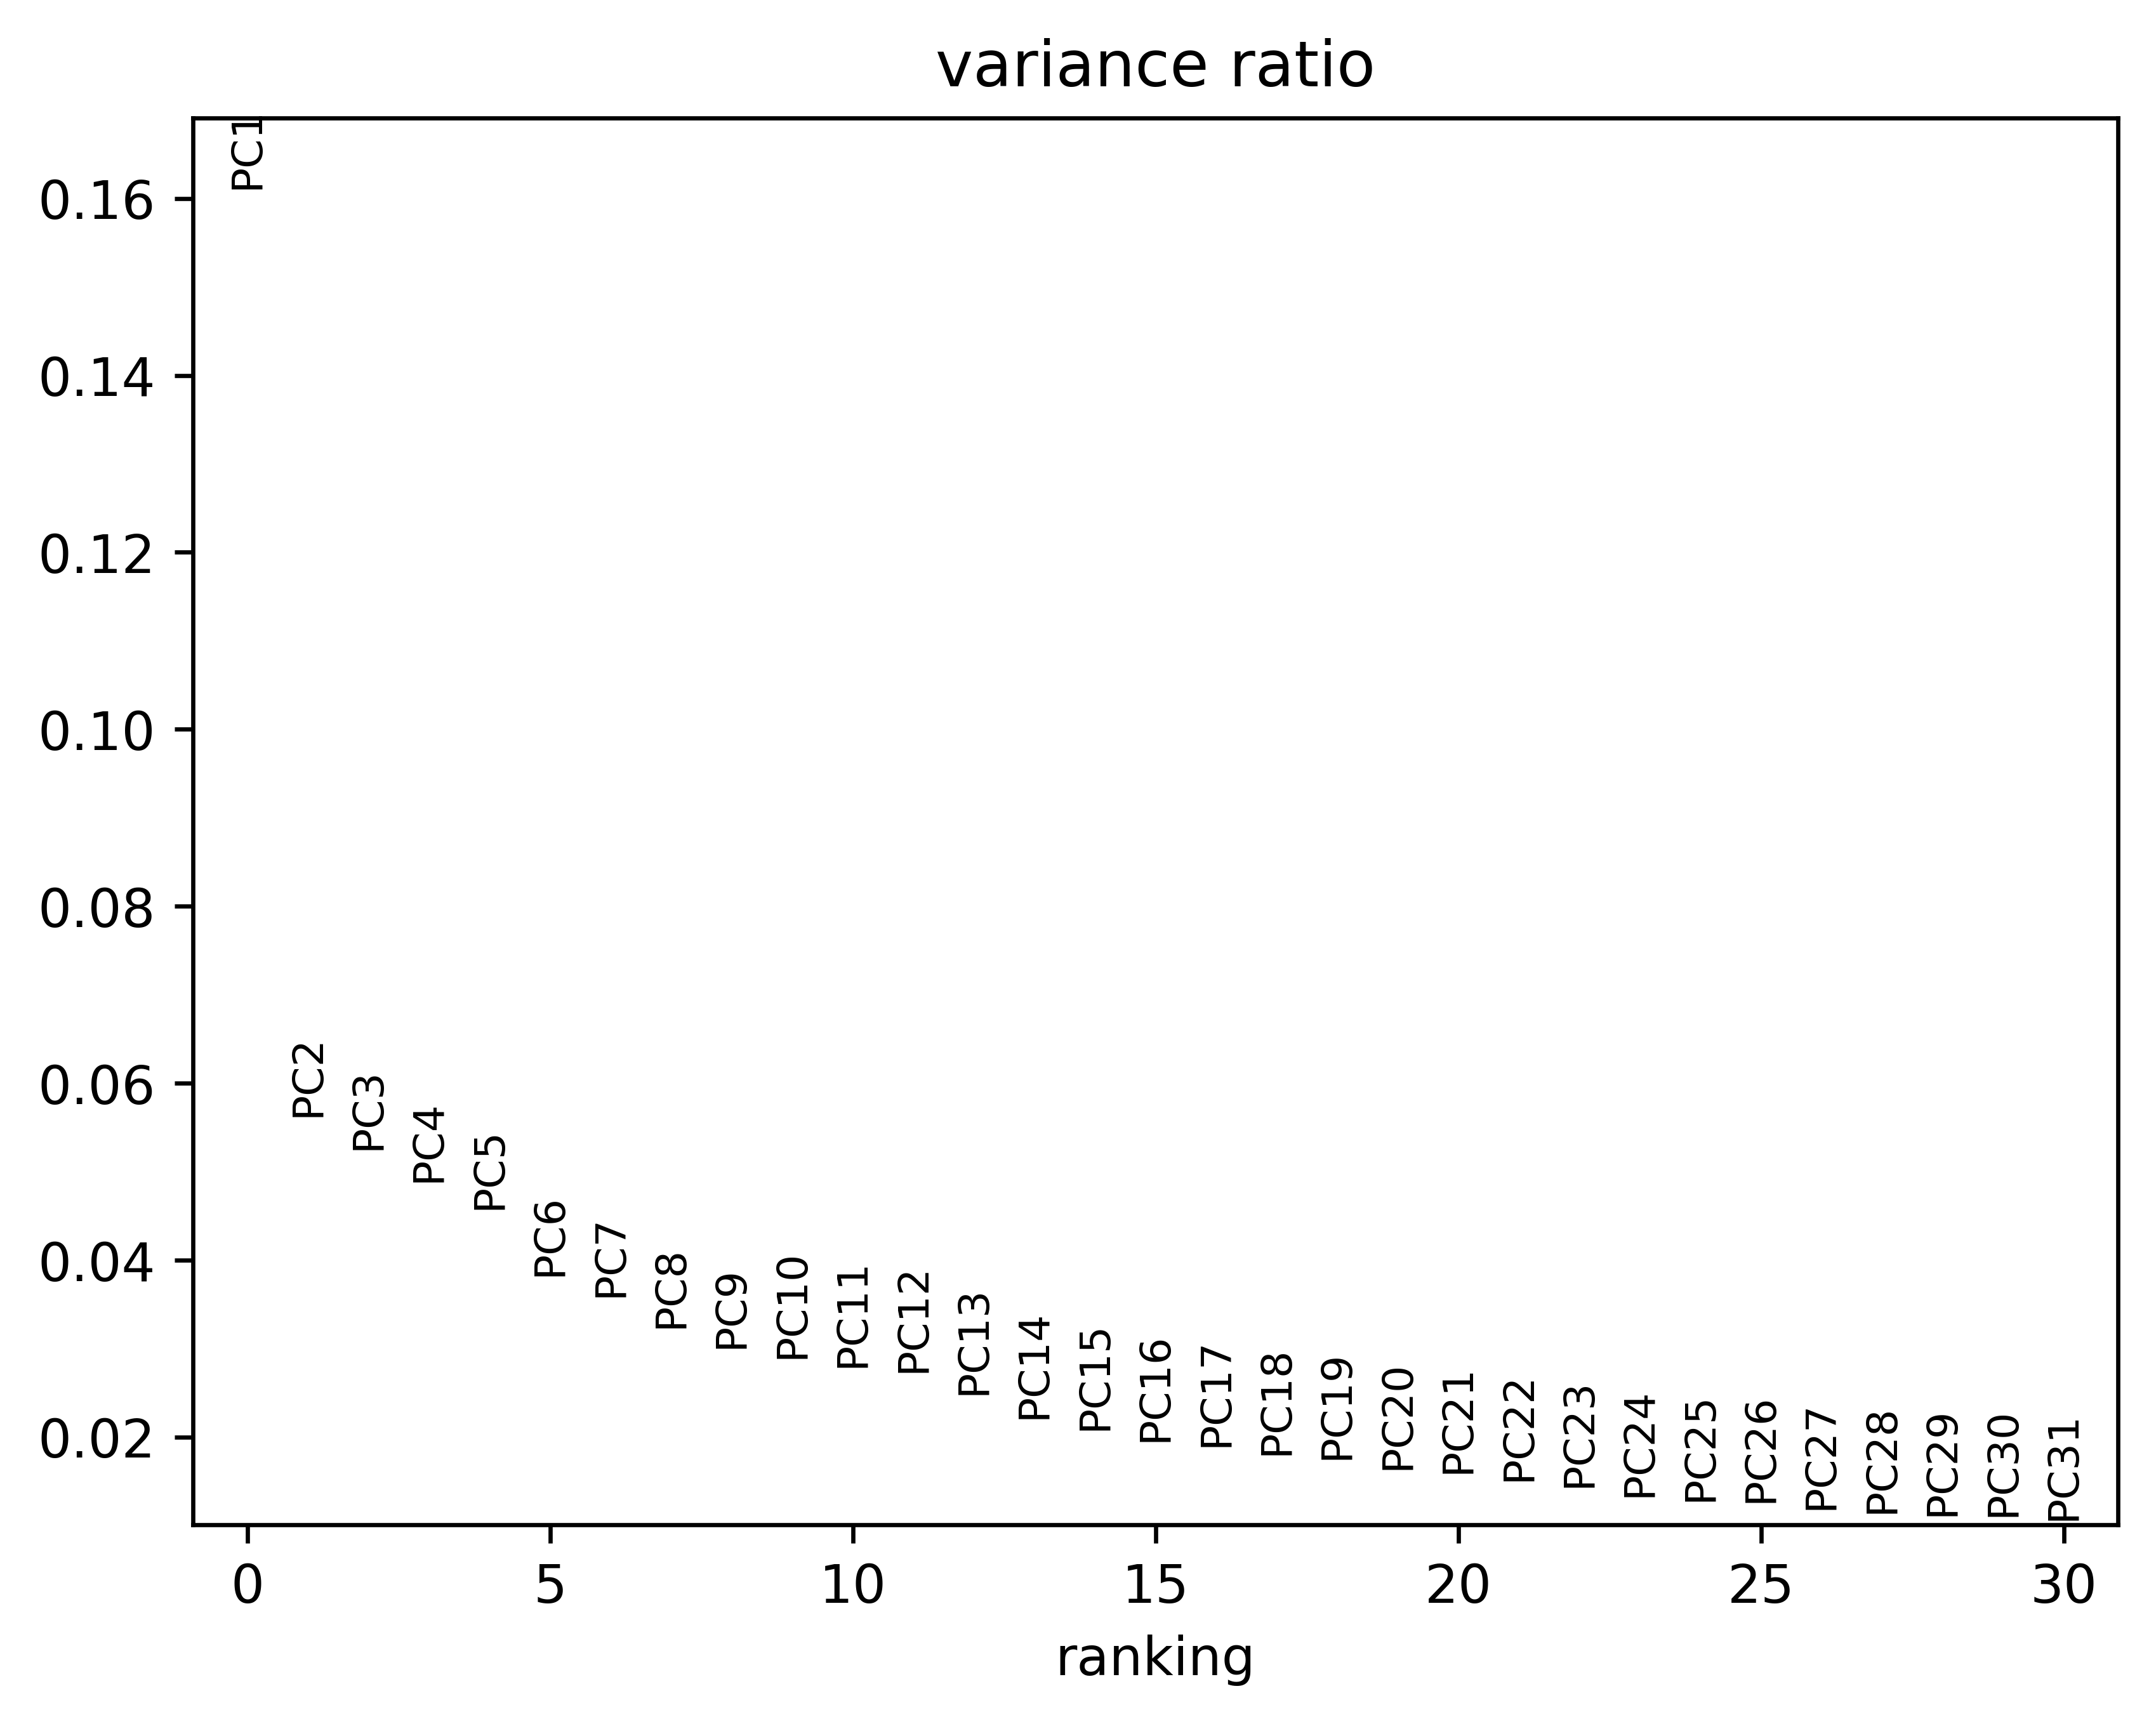

In [ ]:
sc.pl.pca(pdata, color=["patient_ID_v2", "classification_v2", "dataset_v2"], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

In [ ]:
pdata_subset = pdata.copy()
pdata_subset.obs = pdata.obs[["patient_ID_v2",  "classification_v2"]]

dc.tl.rankby_obsm(
    pdata_subset,
    key="X_pca",
    uns_key="pca_anova",
)

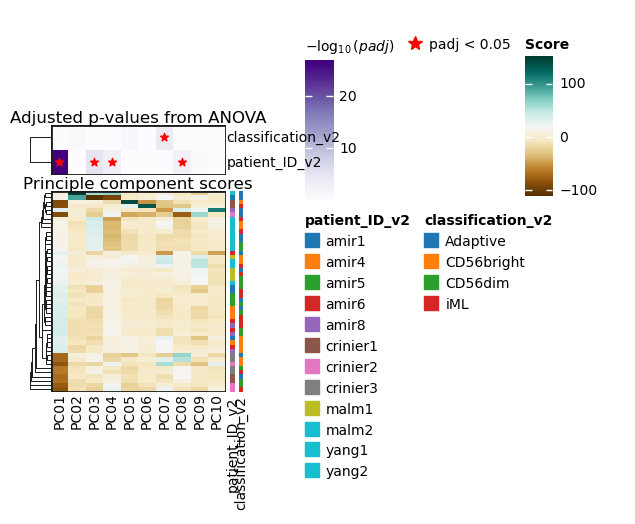

In [ ]:
dc.pl.obsm(
    pdata_subset,
    key="pca_anova",
    names=["patient_ID_v2",  "classification_v2"],
    titles=["Principle component scores", "Adjusted p-values from ANOVA"],
    cmap_obs={},
)

In [ ]:
## iML vs Adaptive

In [ ]:
pds2 = pt.tl.PyDESeq2(adata=pdata, design="~ patient_ID_v2 + classification_v2")

In [ ]:
pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.05 seconds.

Fitting dispersion trend curve...
... done in 0.14 seconds.

Fitting MAP dispersions...
... done in 1.04 seconds.

Fitting LFCs...
... done in 1.23 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 0 outlier genes.



In [ ]:
res_df = pds2.test_contrasts(pds2.contrast(column="classification_v2", baseline="Adaptive", group_to_compare="iML"))

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
CAPRIN2      3.578837        0.009565  0.386117  0.024773  0.980236  0.999231
VIM        167.261813       -0.111467  0.215768 -0.516606  0.605431  0.960199
TRUB2        6.091675        0.470006  0.321737  1.460842  0.144059  0.674241
MED12L       0.249123       -0.739636  1.344893 -0.549959  0.582348       NaN
BTN3A3      16.857916       -0.089319  0.171445 -0.520975  0.602384  0.959992
...               ...             ...       ...       ...       ...       ...
PRELID1     68.630606        0.074997  0.097279  0.770950  0.440737  0.914408
NPR3         0.002141       -1.442558  4.304140 -0.335156  0.737507       NaN
WDR5         2.346506        0.870481  0.549460  1.584249  0.113137  0.626491
DTX3         5.680368        0.313348  0.340641  0.919878  0.357636  0.884512
LINC00667    9.540161        0.207744  0

... done in 0.33 seconds.



In [ ]:
res_df.head(10)

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,FGFBP2,263.683561,-2.579004,0.170352,-15.139228,8.925467e-52,7.853518e-48,None
1,GZMH,190.806847,-1.718633,0.153853,-11.170609,5.679033e-29,2.498491e-25,None
2,CD52,313.035587,-1.578897,0.147691,-10.690561,1.126876e-26,3.305126e-23,None
3,DSTN,85.777458,-1.058575,0.110175,-9.608103,7.389794e-22,1.625570e-18,None
4,S100A4,391.014656,-1.211091,0.132174,-9.162876,5.053217e-20,8.892652e-17,None
5,CD7,421.979236,0.792123,0.089140,8.886296,6.317986e-19,9.265327e-16,None
6,IL2RB,122.466272,0.962469,0.111107,8.662526,4.614244e-18,5.800105e-15,None
7,CST7,468.162650,-0.535409,0.063292,-8.459388,2.687833e-17,2.956280e-14,None
8,CLDND1,47.103498,1.427675,0.172501,8.276315,1.270461e-16,1.242088e-13,None
9,GZMK,49.195404,4.552454,0.552352,8.241951,1.694255e-16,1.490775e-13,None


In [ ]:

filtered_res_df = res_df[res_df['adj_p_value'] < 0.05]
print(filtered_res_df)

     variable    baseMean    log_fc     lfcSE       stat       p_value  \
0      FGFBP2  263.683561 -2.579004  0.170352 -15.139228  8.925467e-52   
1        GZMH  190.806847 -1.718633  0.153853 -11.170609  5.679033e-29   
2        CD52  313.035587 -1.578897  0.147691 -10.690561  1.126876e-26   
3        DSTN   85.777458 -1.058575  0.110175  -9.608103  7.389794e-22   
4      S100A4  391.014656 -1.211091  0.132174  -9.162876  5.053217e-20   
..        ...         ...       ...       ...        ...           ...   
281   FAM120A   11.160284  0.802326  0.253705   3.162436  1.564552e-03   
282  TRAPPC6A   28.526220  0.537933  0.170142   3.161680  1.568616e-03   
283    RNF139   22.892390 -0.565651  0.179095  -3.158384  1.586463e-03   
284    PPP3CC   16.120706 -0.674584  0.213838  -3.154648  1.606918e-03   
285     UQCRB  219.265709 -0.193622  0.061415  -3.152675  1.617818e-03   

      adj_p_value contrast  
0    7.853518e-48     None  
1    2.498491e-25     None  
2    3.305126e-23     No

In [ ]:
adata_v2 = adata.copy()

# Ensure raw counts or normalized expression are accessible
expr_matrix = adata_v2.X  # or adata.layers["counts"], depending on what you used

# Get boolean mask for each group
Adaptive_mask = adata_v2.obs["classification_v2"] == "Adaptive"
iml_mask = adata_v2.obs["classification_v2"] == "iML"

# Convert to array if sparse
if not isinstance(expr_matrix, np.ndarray):
    expr_matrix = expr_matrix.toarray()

# Calculate % of cells expressing each gene in each group
Adaptive_expr_percent = np.sum(expr_matrix[Adaptive_mask, :] > 0, axis=0) / np.sum(Adaptive_mask) * 100
iml_expr_percent = np.sum(expr_matrix[iml_mask, :] > 0, axis=0) / np.sum(iml_mask) * 100

# Put results into a DataFrame
percent_expr_df = pd.DataFrame({
    "gene": adata_v2.var_names,
    "Adaptive_percent": Adaptive_expr_percent,
    "iML_percent": iml_expr_percent
})

# Merge on gene name (make sure the DE result column name matches)
merged_res = filtered_res_df.merge(
    percent_expr_df, 
    left_on="variable",   # or "gene_name", depending on your DESeq2 output
    right_on="gene",
    how="left"
)
merged_res = merged_res.drop_duplicates(subset="gene").reset_index(drop=True)

In [ ]:
merged_res

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,gene,Adaptive_percent,iML_percent
0,FGFBP2,263.683561,-2.579004,0.170352,-15.139228,8.925467e-52,7.853518e-48,None,FGFBP2,79.910714,27.047619
1,GZMH,190.806847,-1.718633,0.153853,-11.170609,5.679033e-29,2.498491e-25,None,GZMH,80.357143,37.333333
2,CD52,313.035587,-1.578897,0.147691,-10.690561,1.126876e-26,3.305126e-23,None,CD52,72.767857,41.485714
3,DSTN,85.777458,-1.058575,0.110175,-9.608103,7.389794e-22,1.625570e-18,None,DSTN,43.377976,24.457143
4,S100A4,391.014656,-1.211091,0.132174,-9.162876,5.053217e-20,8.892652e-17,None,S100A4,72.991071,42.019048
...,...,...,...,...,...,...,...,...,...,...,...
281,FAM120A,11.160284,0.802326,0.253705,3.162436,1.564552e-03,4.877122e-02,None,FAM120A,3.943452,7.352381
282,TRAPPC6A,28.526220,0.537933,0.170142,3.161680,1.568616e-03,4.877122e-02,None,TRAPPC6A,9.970238,14.476190
283,RNF139,22.892390,-0.565651,0.179095,-3.158384,1.586463e-03,4.915243e-02,None,RNF139,10.639881,7.009524
284,PPP3CC,16.120706,-0.674584,0.213838,-3.154648,1.606918e-03,4.961146e-02,None,PPP3CC,12.202381,7.276190


In [ ]:
merged_res.to_csv('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/PBMC_combined_Malm_ding_Tcell_filtered/output/Pydeseq2_Malmberg_PBMC_iML_Adaptive_adj_pvalue_<0.05_cells percent_added.csv', index= False)

NaNs encountered, dropping rows with NaNs


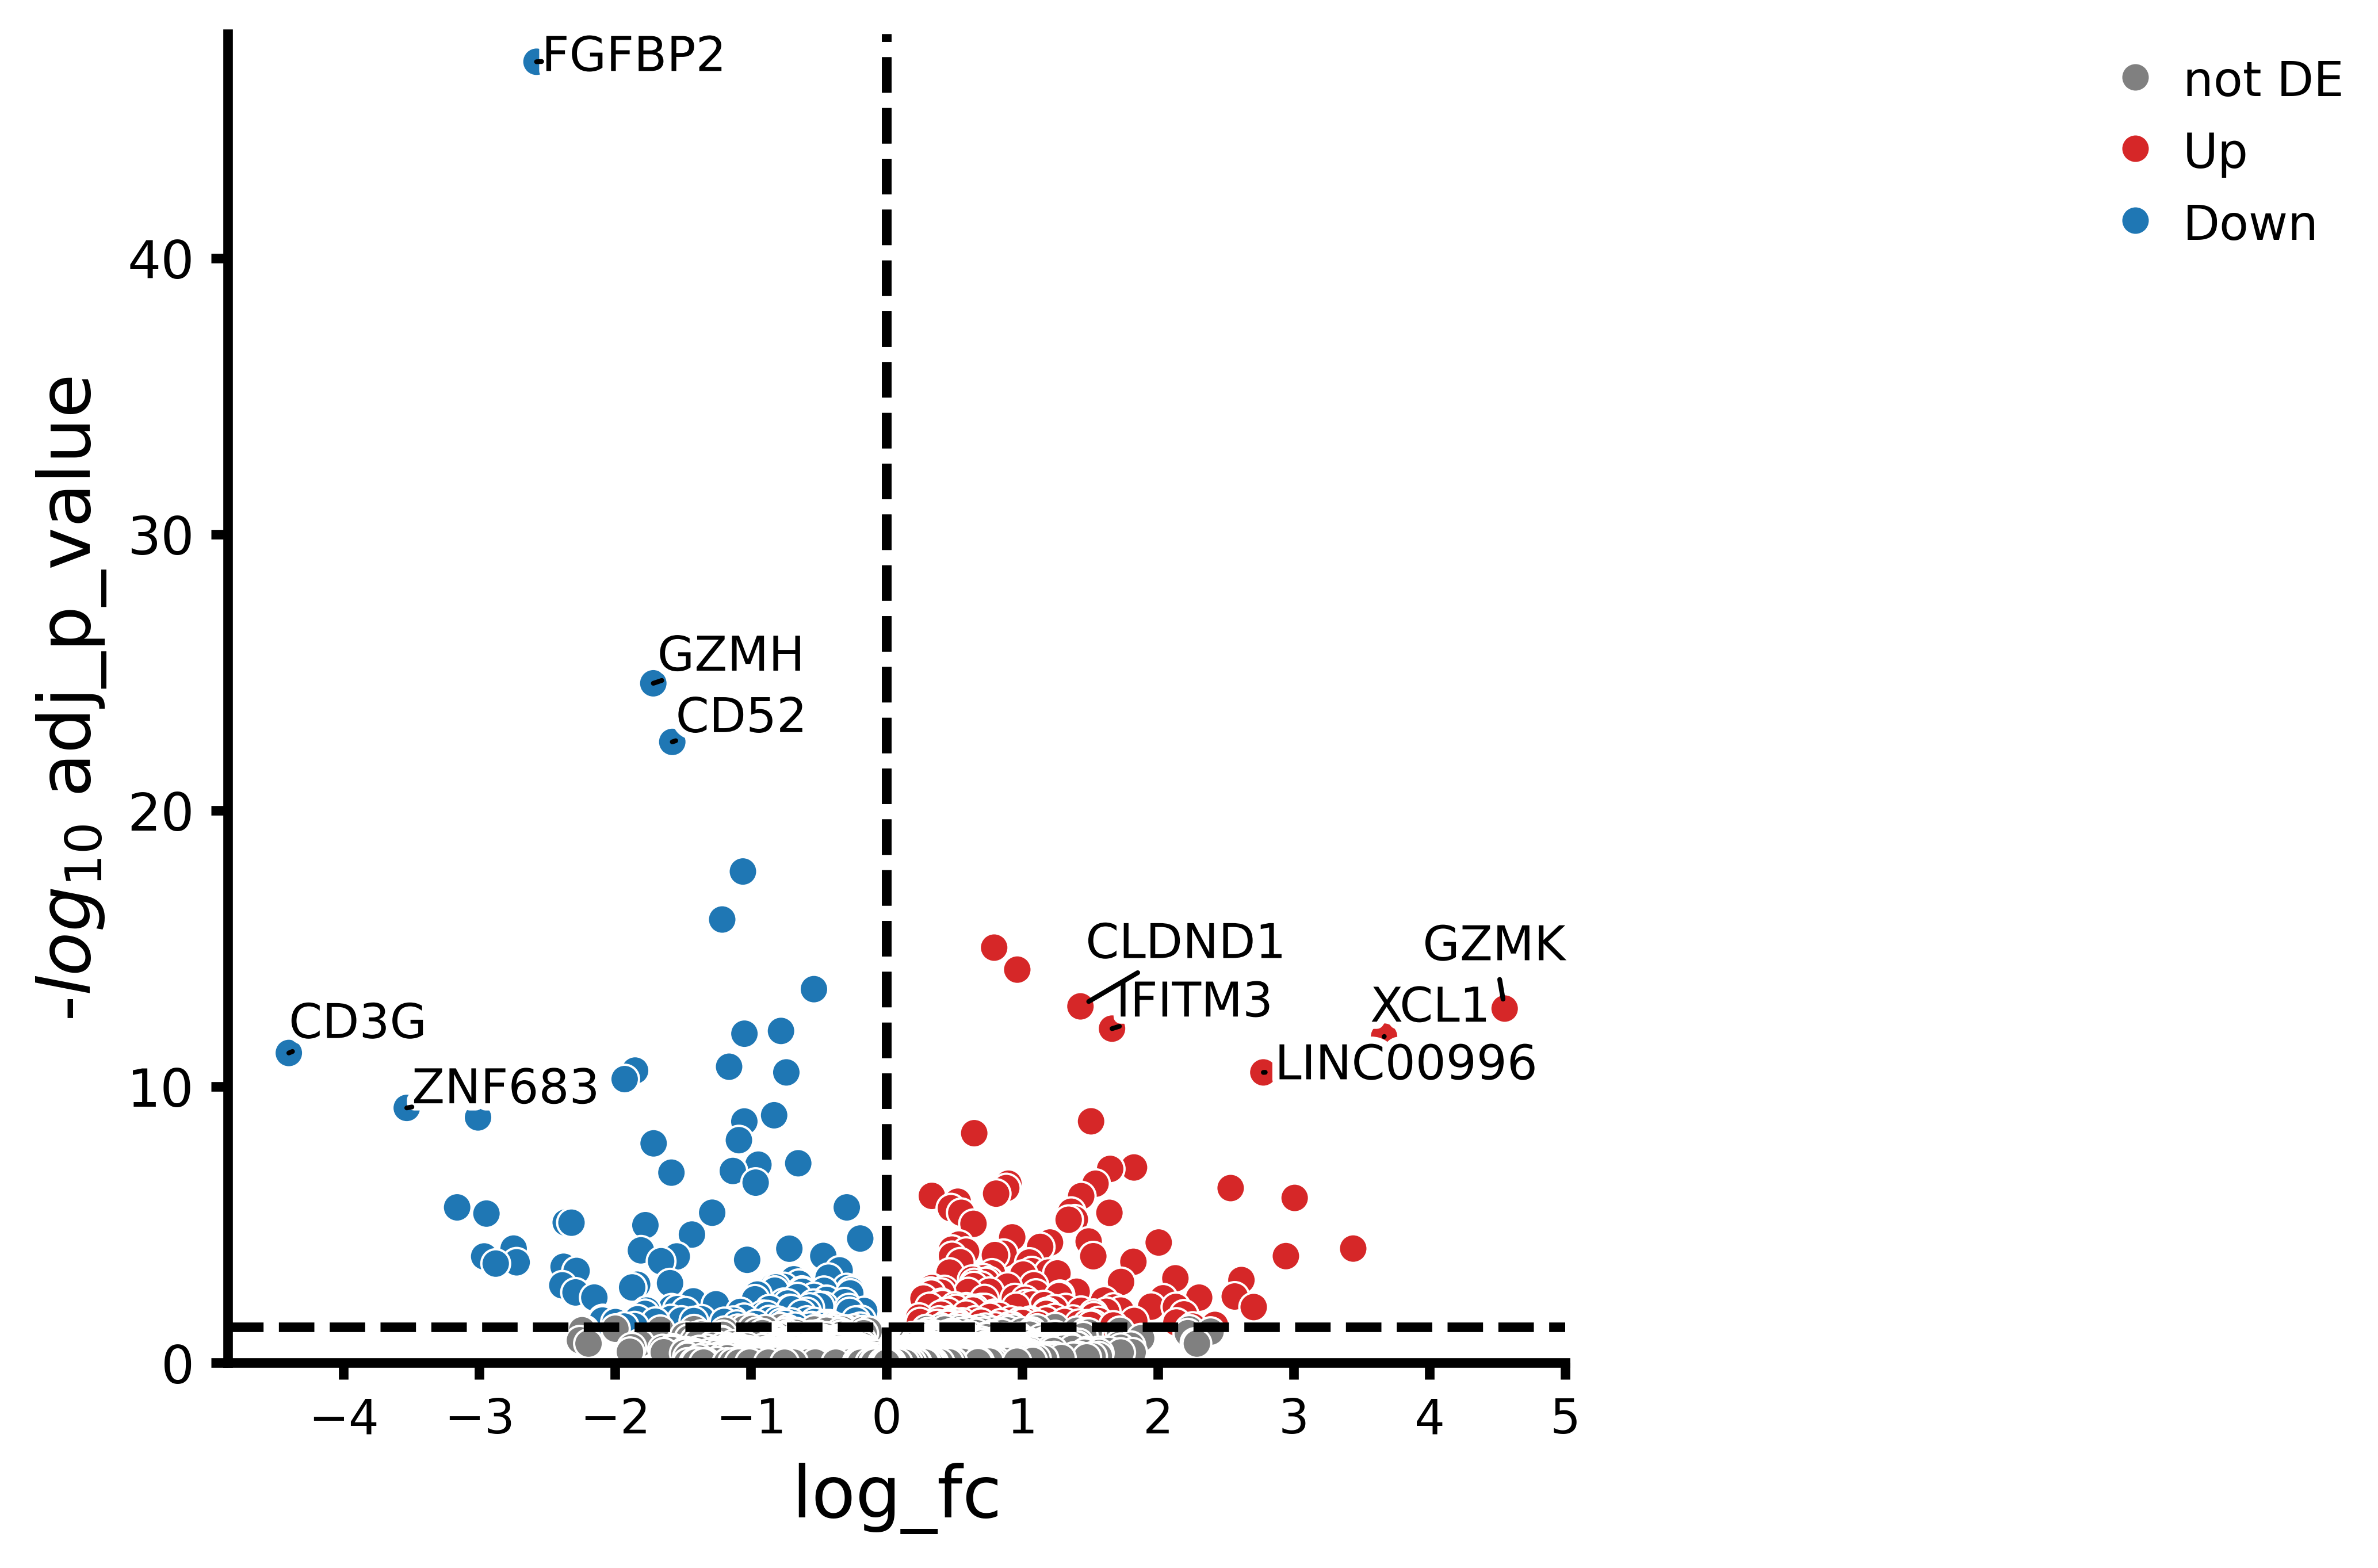

In [ ]:
pds2.plot_volcano(res_df, log2fc_thresh=0)

In [ ]:
import matplotlib.patheffects as path_effects
from adjustText import adjust_text

In [ ]:
filtered_res_df= res_df

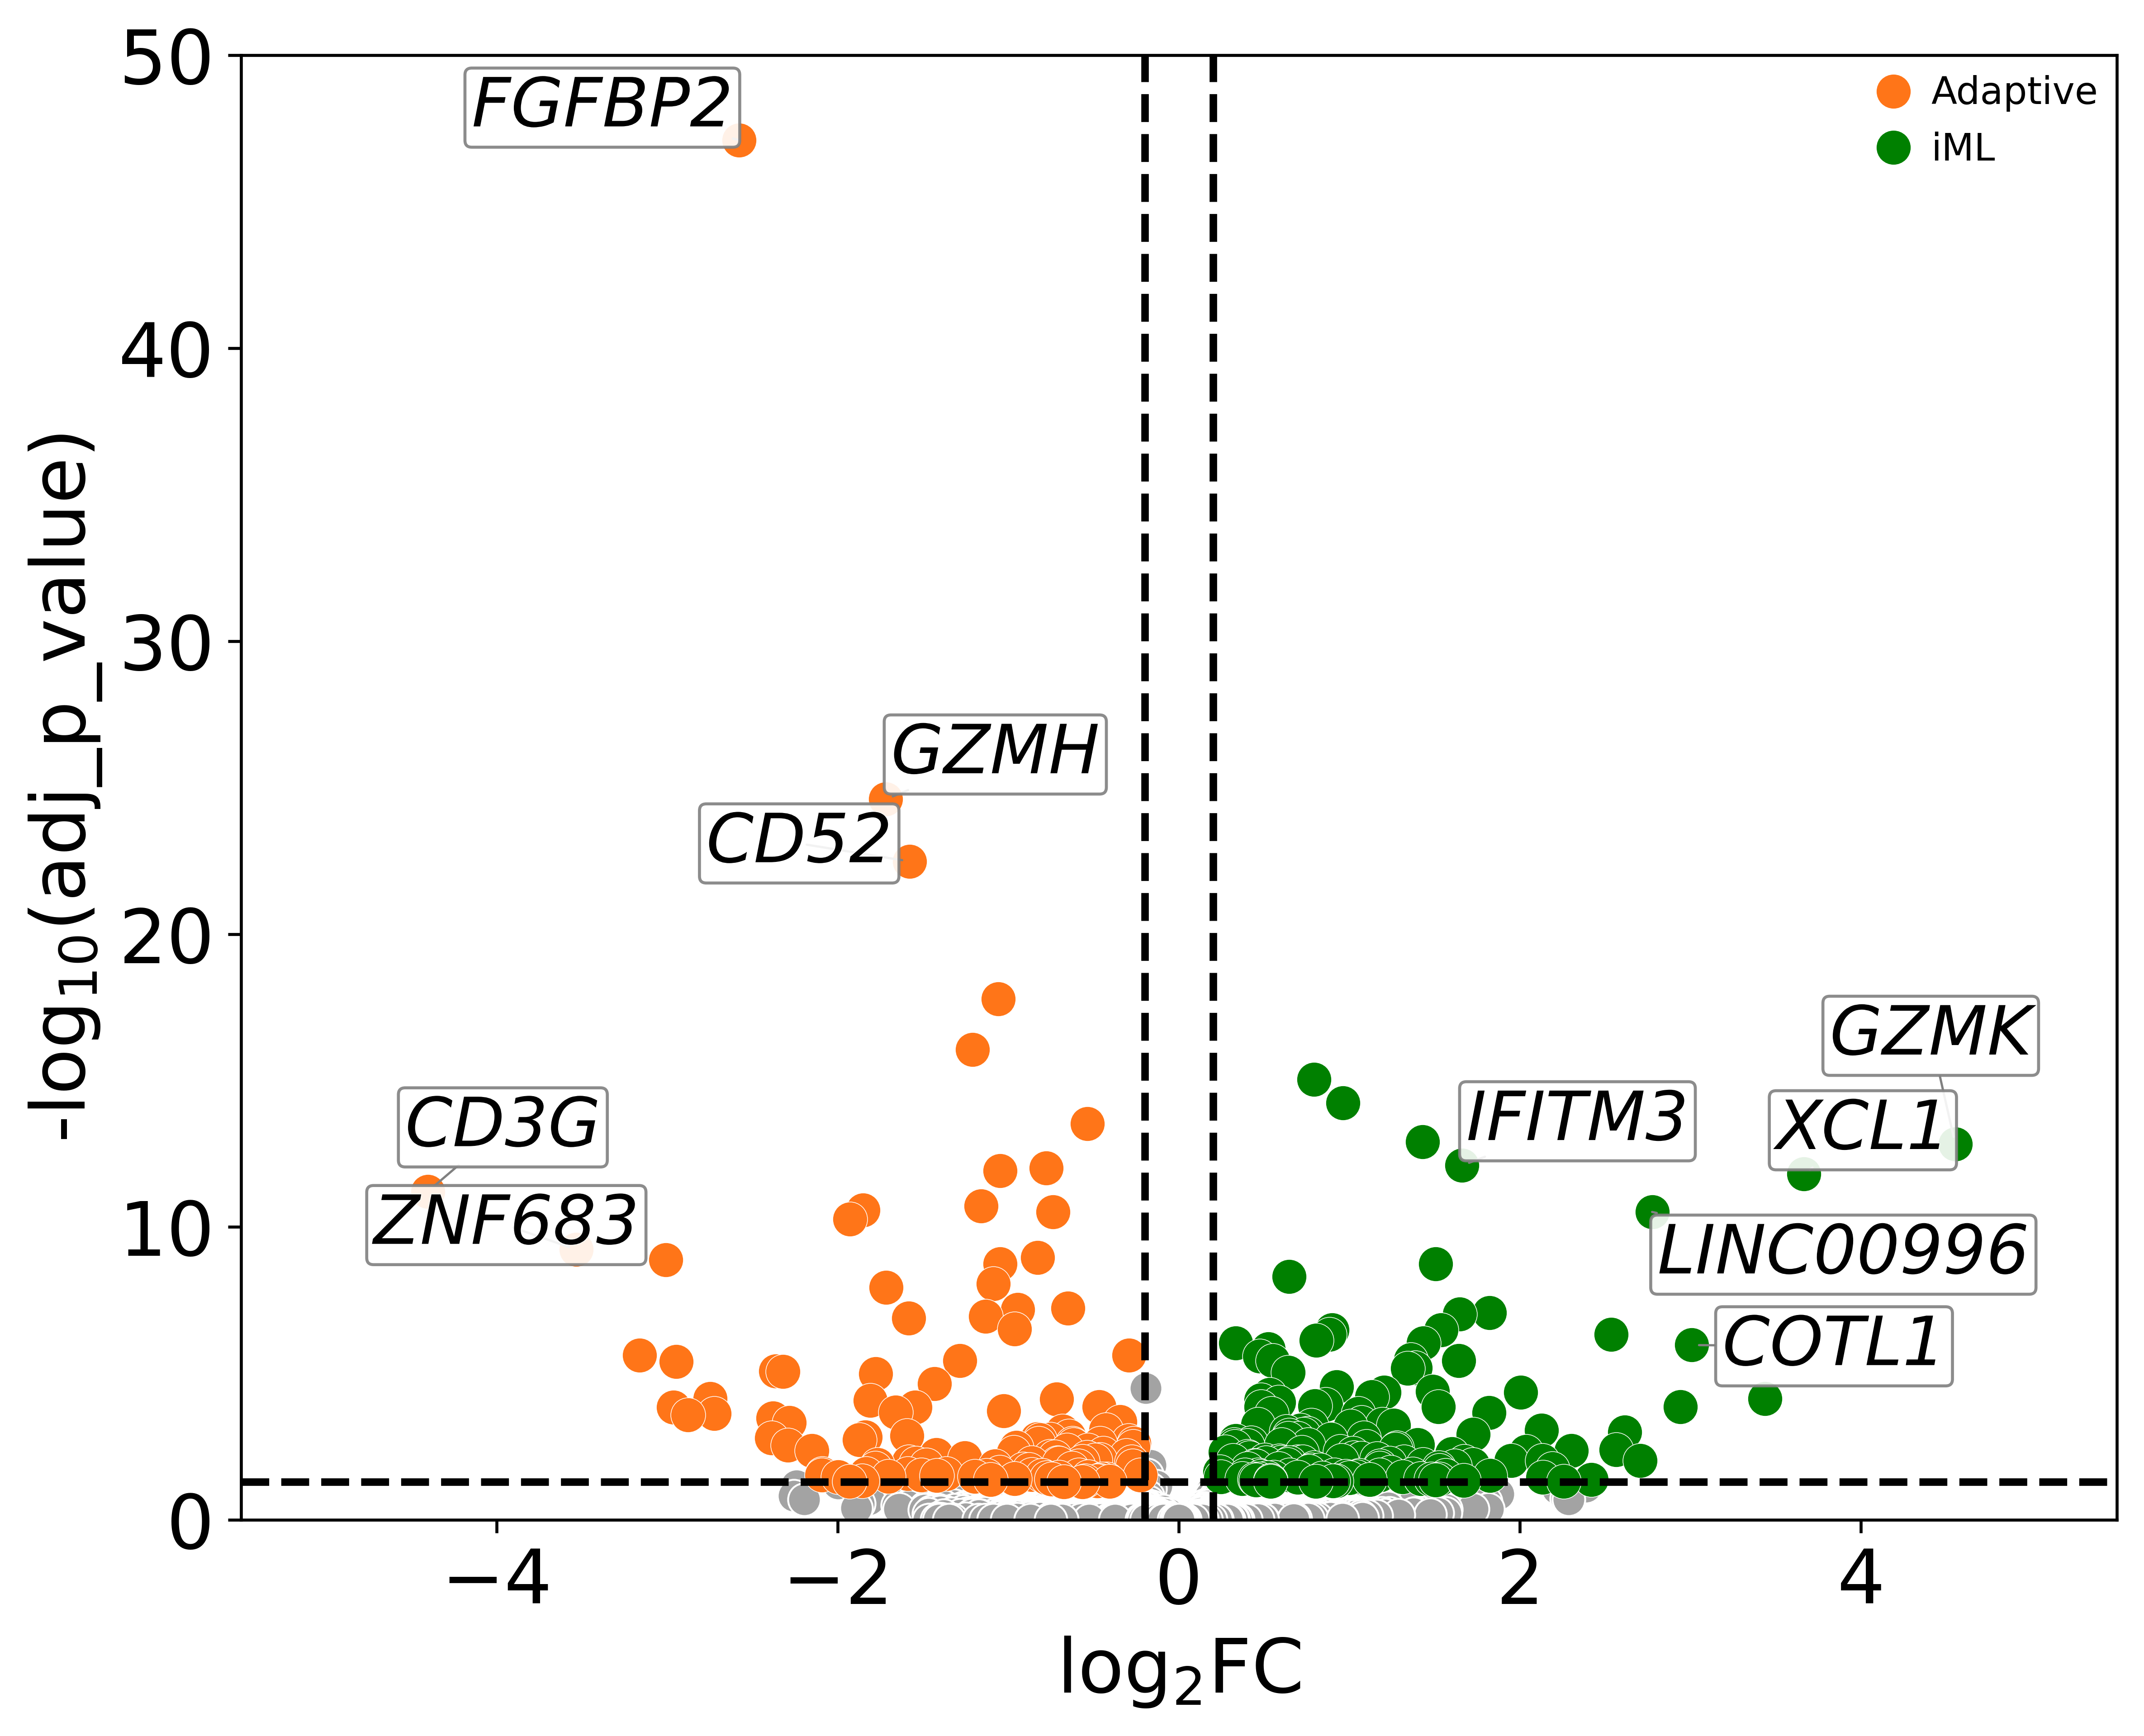

In [ ]:
filtered_res_df = filtered_res_df[(filtered_res_df["log_fc"] > -5) & (filtered_res_df["log_fc"] < 5)]

# Ensure gene names are in index
filtered_res_df = filtered_res_df.set_index("variable", drop=False)
filtered_res_df["-log10(adj_p_value)"] = -np.log10(filtered_res_df["adj_p_value"])

plt.figure(figsize=(8,6.5))

# ----Significance thresholds
pval_threshold = 0.05
logfc_threshold = 0.2

# Plot all genes in light gray
plt.scatter(
    filtered_res_df["log_fc"], 
    filtered_res_df["-log10(adj_p_value)"], 
    color="#a3a3a3", s=75, label="_nolegend_",
    edgecolors="white", linewidth=0.5
)

#  Identify significant up/down genes
sig_up = filtered_res_df[(filtered_res_df["log_fc"] > logfc_threshold) & 
                         (filtered_res_df["adj_p_value"] < pval_threshold)]
sig_down = filtered_res_df[(filtered_res_df["log_fc"] < -logfc_threshold) & 
                           (filtered_res_df["adj_p_value"] < pval_threshold)]

# ----Overlay significant genes
plt.scatter(
    sig_down["log_fc"], 
    sig_down["-log10(adj_p_value)"], 
    facecolors='#FF7518',        # White fill
    edgecolors="white",        # White outline
    linewidth=0.18,             # Adjust outline thickness
    s=85, 
    label="Adaptive"
)

plt.scatter(
    sig_up["log_fc"], 
    sig_up["-log10(adj_p_value)"], 
    facecolors="green",        # Green fill
    edgecolors="white",        # White outline
    linewidth=0.18,             # Adjust outline thickness
    s=85, 
    label="iML"
)


# ----Label genes of interest
genes_to_label = ["CD3G", "ZNF683", "CD52", "GZMH", "FGFBP2", "IFITM3", "GZMK", "LINC00996", "XCL1", "COTL1" ]

texts = []
for gene in genes_to_label:
    if gene in filtered_res_df.index:
        x = filtered_res_df.loc[gene, "log_fc"]
        y = filtered_res_df.loc[gene, "-log10(adj_p_value)"]
        text = plt.text(
            x, y, gene, fontsize=18, color="black",
            ha='left' if x > 0 else 'right', fontstyle='italic',
                                bbox=dict(
        boxstyle='round,pad=0.1',
        facecolor='white',
        edgecolor='gray',
        linewidth=0.8,
        alpha=0.9)
        )
        # ➕ Add white outline around text
        text.set_path_effects([
            path_effects.Stroke(linewidth=0.3, foreground='white'),
            path_effects.Normal()
        ])
        texts.append(text)


# ----- Adjust label positions
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.6),
    only_move={'points':'y', 'texts':'xy'},
    force_text=0.5
)

# -------Reference line + labels
#plt.axvline(0, color="black", linestyle="--", lw=2.2)
plt.axhline(-np.log10(pval_threshold), color="black", linestyle="--",  lw=2)
plt.axvline(logfc_threshold, color="black", linestyle="--", lw=2)
plt.axvline(-logfc_threshold, color="black", linestyle="--", lw=2)
plt.ylim(0,50)

# Make x-axis symmetric
xmax = max(abs(filtered_res_df["log_fc"].min()), abs(filtered_res_df["log_fc"].max()))
plt.xlim(-5.5, 5.5)
plt.xlabel("log$_2$FC", fontsize=20)
plt.ylabel(r"-log$_{10}$(adj_p_value)", fontsize= 20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

#plt.title("Volcano Plot - Malmberg PBMC iML vs Adaptive")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
